In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Path al dataset
DATA_PATH = "NuclearPowerPlantAccidentData/Operation_csv_data"

# Vediamo le cartelle disponibili (tipi di condizioni)
conditions = sorted(os.listdir(DATA_PATH))
print(conditions)

['ATWS', 'FLB', 'LACP', 'LLB', 'LOCA', 'LOCAC', 'LOF', 'LR', 'MD', 'Normal', 'RI', 'RW', 'SGATR', 'SGBTR', 'SLBIC', 'SLBOC', 'SP', 'TT']


In [3]:
# File nella condizione normale
normal_files = sorted(os.listdir(os.path.join(DATA_PATH, "Normal")))
print("Normal:", normal_files)

# File in un incidente, es. LOCA
loca_files = sorted(os.listdir(os.path.join(DATA_PATH, "LOCA")))
print("LOCA:", loca_files)

Normal: ['1.csv']
LOCA: ['1.csv', '10.csv', '100.csv', '11.csv', '12.csv', '13.csv', '14.csv', '15.csv', '16.csv', '17.csv', '18.csv', '19.csv', '2.csv', '20.csv', '21.csv', '22.csv', '23.csv', '24.csv', '25.csv', '26.csv', '27.csv', '28.csv', '29.csv', '3.csv', '30.csv', '31.csv', '32.csv', '33.csv', '34.csv', '35.csv', '36.csv', '37.csv', '38.csv', '39.csv', '4.csv', '40.csv', '41.csv', '42.csv', '43.csv', '44.csv', '45.csv', '46.csv', '47.csv', '48.csv', '49.csv', '5.csv', '50.csv', '51.csv', '52.csv', '53.csv', '54.csv', '55.csv', '56.csv', '57.csv', '58.csv', '59.csv', '6.csv', '60.csv', '61.csv', '62.csv', '63.csv', '64.csv', '65.csv', '66.csv', '67.csv', '68.csv', '69.csv', '7.csv', '70.csv', '71.csv', '72.csv', '73.csv', '74.csv', '75.csv', '76.csv', '77.csv', '78.csv', '79.csv', '8.csv', '80.csv', '81.csv', '82.csv', '83.csv', '84.csv', '85.csv', '86.csv', '87.csv', '88.csv', '89.csv', '9.csv', '90.csv', '91.csv', '92.csv', '93.csv', '94.csv', '95.csv', '96.csv', '97.csv', '98

In [4]:
# Carichiamo il file normale
df_normal = pd.read_csv(os.path.join(DATA_PATH, "Normal", "1.csv"))
print("Shape:", df_normal.shape)
print("\nPrime colonne:")
print(df_normal.head())

Shape: (302, 97)

Prime colonne:
   TIME           P        TAVG         THA         THB         TCA  \
0   0.0  155.500015  310.000000  327.823975  327.823212  292.176056   
1  10.0  155.484879  310.024261  327.775848  327.774994  292.230438   
2  20.0  155.521729  310.098785  327.662140  327.661285  292.465179   
3  30.0  155.554138  310.180511  327.484039  327.483185  292.798828   
4  40.0  155.577545  310.265991  327.271820  327.270935  293.174561   

          TCB          WRCA          WRCB       PSGA  ...  MDBR  MCRT  MGAS  \
0  292.176788  16515.818359  33031.636719  67.000031  ...   0.0   0.0   0.0   
1  292.231201  16515.818359  33031.636719  67.137077  ...   0.0   0.0   0.0   
2  292.466064  16515.818359  33031.636719  67.472702  ...   0.0   0.0   0.0   
3  292.799713  16515.818359  33031.636719  67.887314  ...   0.0   0.0   0.0   
4  293.175415  16515.818359  33031.636719  68.332588  ...   0.0   0.0   0.0   

   TCRT  TSLP    PPM  RRCA  RRCB  RRCO  WFLB  
0  50.0  50.0  200

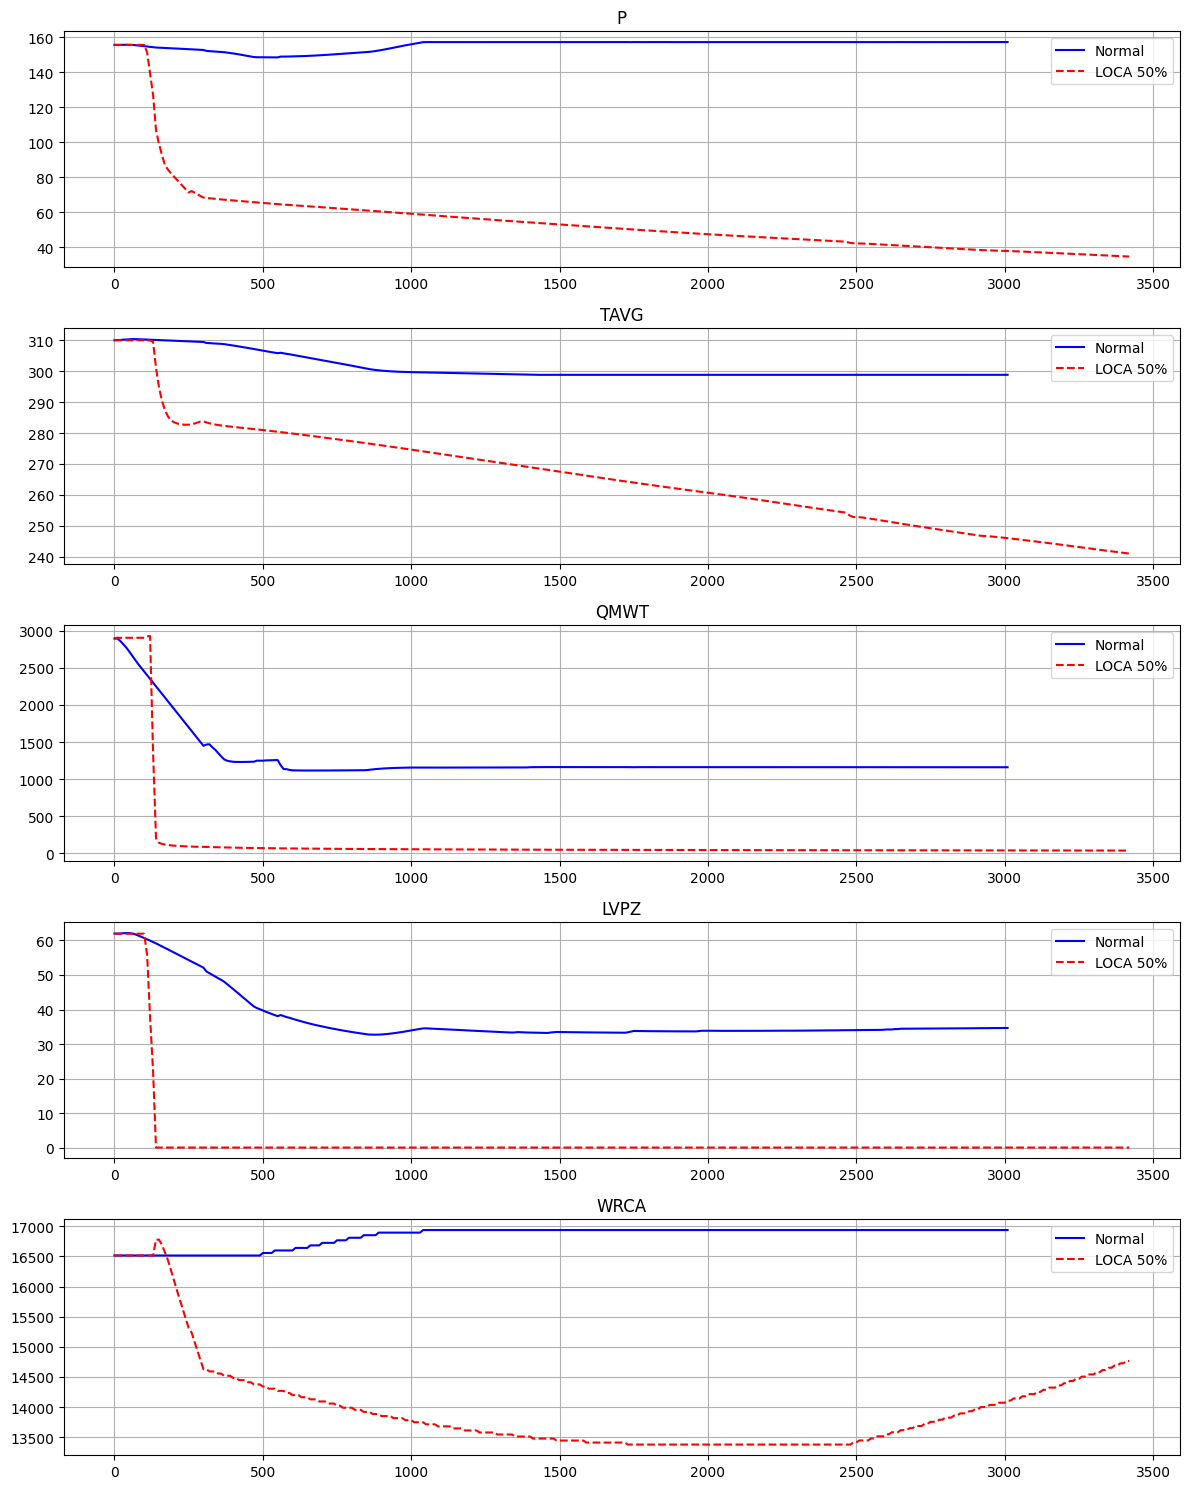

In [5]:
# Carichiamo un LOCA (severità media, es. 50)
df_loca = pd.read_csv(os.path.join(DATA_PATH, "LOCA", "50.csv"))

# Parametri più significativi da visualizzare
params = ["P", "TAVG", "QMWT", "LVPZ", "WRCA"]

fig, axes = plt.subplots(len(params), 1, figsize=(12, 15))

for i, param in enumerate(params):
    axes[i].plot(df_normal["TIME"], df_normal[param], label="Normal", color="blue")
    axes[i].plot(df_loca["TIME"], df_loca[param], label="LOCA 50%", color="red", linestyle="--")
    axes[i].set_title(param)
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [6]:
# Contiamo i campioni per condizione
print(f"{'Condizione':<10} {'N. file':<10} {'Timestep per file'}")
print("-" * 40)
for cond in conditions:
    files = os.listdir(os.path.join(DATA_PATH, cond))
    # Leggiamo uno per vedere quanti timestep ha
    df_tmp = pd.read_csv(os.path.join(DATA_PATH, cond, files[0]))
    print(f"{cond:<10} {len(files):<10} {len(df_tmp)}")

Condizione N. file    Timestep per file
----------------------------------------
ATWS       1          580
FLB        100        162
LACP       1          504
LLB        101        539
LOCA       100        385
LOCAC      100        445
LOF        1          512
LR         99         556
MD         100        553
Normal     1          302
RI         100        316
RW         100        157
SGATR      100        402
SGBTR      110        432
SLBIC      101        182
SLBOC      100        433
SP         1          515
TT         1          721


In [7]:
# Riepilogo totale
total_normal = 302
total_anomaly = sum([
    len(os.listdir(os.path.join(DATA_PATH, cond))) * 
    len(pd.read_csv(os.path.join(DATA_PATH, cond, 
        os.listdir(os.path.join(DATA_PATH, cond))[0])))
    for cond in conditions if cond != "Normal"
])

print(f"Timestep normali:  {total_normal}")
print(f"Timestep anomali:  {total_anomaly}")
print(f"Rapporto anomalie/normale: {total_anomaly/total_normal:.1f}x")

Timestep normali:  302
Timestep anomali:  463517
Rapporto anomalie/normale: 1534.8x
